# Climate Change Trend Analysis and Forecasting

**IDEAS TIH Summer Internship 2026**  
**Mentor:** Sauparna Sarkar  
**Team:** *(fill in your names)*

---

## Table of Contents

- [Week 1 — Data Acquisition, Exploration and Understanding](#week1)
  - [1.0 Imports & Constants](#10-imports)
  - [1.1 Data Loading](#11-data-loading)
  - [1.2 Data Profiling](#12-data-profiling)
  - [1.3 Exploratory Data Analysis](#13-eda)
- [Week 2 — Feature Engineering](#week2)
  - [2.1 Time-Based Features](#21-time-based)
  - [2.2 Lag Features](#22-lag)
  - [2.3 Per-Capita and Intensity Features](#23-intensity)
  - [2.4 Growth Rate Features](#24-growth)
  - [2.5 Final Feature Dataset](#25-final)
- [Week 3 — Baseline ML Models: Regression](#week3)
  - [3.1 Problem Framing](#31-framing)
  - [3.2 Train-Test Split](#32-split)
  - [3.3 Naive Baseline](#33-naive)
  - [3.4 Linear Regression](#34-lr)
  - [3.5 Random Forest Regressor — Per Country](#35-rf-pc)
  - [3.6 Random Forest Regressor — Pooled](#36-rf-pooled)
  - [3.7 Model Comparison Table](#37-comparison)
- [Week 4 — Time-Series Forecasting with ETS(A,Ad,N)](#week4)
  - [4.1 Concept Introduction](#41-concept)
  - [4.2 Model Fitting](#42-model-fitting)
  - [4.3 Forecasting to 2043](#43-forecasting)
  - [4.4 Trend Interpretation](#44-trend)
  - [4.5 Forecast Summary Table](#45-forecast-table)
  - [4.6 Model Validation](#46-validation)
- [Week 5 — Scenario Analysis *(Optional)*](#week5)
- [Week 6 — Notebook Finalisation](#week6)
- [Week 7 — Final Presentation](#week7)

---
<a id='week1'></a>
# Week 1 — Data Acquisition, Exploration and Understanding

**Learning Objective:** Understand the structure and content of GHG datasets and produce a clean, profiled dataset ready for analysis.

> **Notebook standard (apply throughout):** Every code cell must be preceded by a markdown cell explaining *what the code does and why*. All charts must have titles, axis labels, and legends. All variable names must be descriptive — no single-letter names except loop counters.


<a id='10-imports'></a>
### 1.0 Imports

Import all libraries needed for the entire project here. Add to this cell as you progress through the weeks.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

### Project Constants

Shared across all week notebooks via `constants.py` (single source of truth for `COUNTRIES`, `NON_SOVEREIGN`, `FEATURES`, `TARGET`, etc.).


In [2]:
from constants import *


<a id='11-data-loading'></a>
### 1.1 Data Loading

**What to do:** Load the OWID CO₂ dataset from `OWID_URL` (or `data/owid-co2-data.csv` if downloaded locally). Display the first 10 rows, all column names, data types, and the shape of the DataFrame.

**Key columns:**

| Column | Description |
|--------|-------------|
| `country` | Country or region name |
| `year` | Year of observation |
| `co2` | Annual CO₂ emissions (million tonnes) |
| `co2_per_capita` | CO₂ per person (tonnes/person) |
| `methane` | Methane emissions, CO₂-equivalent (MtCO₂e) |
| `nitrous_oxide` | N₂O emissions, CO₂-equivalent (MtCO₂e) |
| `total_ghg` | Total GHG emissions (MtCO₂e) |
| `gdp` | GDP in international dollars |
| `population` | Population |


In [3]:
import urllib.request

LOCAL_PATH = "../data/owid-co2-data.csv"

if os.path.exists(LOCAL_PATH):
    df_raw = pd.read_csv(LOCAL_PATH)
    print(f"Loaded from local file: {LOCAL_PATH}")
else:
    print("Local file not found — fetching from OWID URL (~50 MB, may take a moment)...")
    print("Tip: if this fails, download manually — see README §4 or run:")
    print(f"  curl -o data/owid-co2-data.csv {OWID_URL}")
    urllib.request.urlretrieve(OWID_URL, LOCAL_PATH)   # saves raw bytes; avoids corrupt-on-interrupt risk of parse→to_csv
    print(f"Saved to {LOCAL_PATH}")
    df_raw = pd.read_csv(LOCAL_PATH)

print(f"\nShape: {df_raw.shape}")
print(f"\nColumn names:\n{df_raw.columns.tolist()}")
print(f"\nData types:\n{df_raw.dtypes.to_string()}")
print("\nDataframe Info:")
df_raw.info()
print("\nFirst 10 rows:")
display(df_raw.head(10))
print("\nDataframe description:")
display(df_raw.describe())

Loaded from local file: ../data/owid-co2-data.csv

Shape: (50411, 79)

Column names:
['country', 'year', 'iso_code', 'population', 'gdp', 'cement_co2', 'cement_co2_per_capita', 'co2', 'co2_growth_abs', 'co2_growth_prct', 'co2_including_luc', 'co2_including_luc_growth_abs', 'co2_including_luc_growth_prct', 'co2_including_luc_per_capita', 'co2_including_luc_per_gdp', 'co2_including_luc_per_unit_energy', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy', 'coal_co2', 'coal_co2_per_capita', 'consumption_co2', 'consumption_co2_per_capita', 'consumption_co2_per_gdp', 'cumulative_cement_co2', 'cumulative_co2', 'cumulative_co2_including_luc', 'cumulative_coal_co2', 'cumulative_flaring_co2', 'cumulative_gas_co2', 'cumulative_luc_co2', 'cumulative_oil_co2', 'cumulative_other_co2', 'energy_per_capita', 'energy_per_gdp', 'flaring_co2', 'flaring_co2_per_capita', 'gas_co2', 'gas_co2_per_capita', 'ghg_excluding_lucf_per_capita', 'ghg_per_capita', 'land_use_change_co2', 'land_use_change_co2_per_ca

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,2802560.0,NaN,0.0,0.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Afghanistan,1755,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Afghanistan,1756,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Afghanistan,1757,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Afghanistan,1758,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Afghanistan,1759,AFG,NaN,NaN,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Dataframe description:


,year,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,co2_including_luc,co2_including_luc_growth_abs,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
count,50411.000000,4.116700e+04,1.525100e+04,29173.000000,25648.000000,29384.000000,27216.000000,26239.000000,23796.000000,23496.000000,...,2170.000000,41238.000000,38280.000000,41238.000000,41238.000000,38280.000000,38150.000000,37813.000000,4712.000000,4712.000000
mean,1920.349249,6.017294e+07,3.300495e+11,7.890109,0.060026,420.227035,6.268847,42.598225,544.144592,7.483698,...,7.190616,2.272236,0.002871,0.008014,0.011224,0.000509,490.799608,310.521459,-6.986781,21.468641
std,65.859123,3.308412e+08,3.086383e+12,62.988171,0.123566,1972.092032,62.199548,1721.913018,2273.281696,99.512520,...,17.448980,9.282343,0.015362,0.045687,0.062888,0.003048,2414.076755,1812.363570,259.018184,62.637598
min,1750.000000,2.150000e+02,4.998000e+07,0.000000,0.000000,0.000000,-1928.339000,-100.000000,-84.560000,-2298.978000,...,0.000000,-0.824000,-0.001000,-0.000000,-0.001000,0.000000,-19.725000,0.000000,-2177.807000,-98.281000
25%,1875.000000,3.272140e+05,7.874038e+09,0.000000,0.000000,0.381000,-0.005000,-1.070500,6.667750,-0.727500,...,0.144000,0.003000,0.000000,0.000000,0.000000,0.000000,1.502000,0.221000,-2.262250,-6.828750
50%,1925.000000,2.291264e+06,2.743861e+10,0.000000,0.001000,5.081000,0.044000,3.813000,28.120000,0.112000,...,0.588500,0.081000,0.000000,0.000000,0.000000,0.000000,14.605500,2.222000,1.641000,8.381500
75%,1975.000000,9.986553e+06,1.212627e+11,0.524000,0.077000,53.656500,1.018000,10.884000,124.303250,2.765250,...,2.416500,0.373000,0.000000,0.001000,0.002000,0.000000,76.508500,27.863000,11.425500,32.782250
max,2024.000000,8.161973e+09,1.301126e+14,1666.885000,2.484000,38598.578000,1804.657000,180870.000000,43184.086000,2614.874000,...,100.000000,100.000000,0.377000,1.216000,1.678000,0.085000,54433.398000,43714.777000,1768.846000,1023.042000


**Validating against the previous download:** `data/owid-co2-data.csv` is refreshed on a
schedule by an external job that backs up the old file to `owid-co2-data.csv.bak-YYYYMMDD`
before downloading the new one. If such a backup exists, compare `df_raw` against it:
structural problems (a required column disappearing, one of the 10 focus `COUNTRIES`
vanishing, or an implausible drop in row count) `raise` immediately, halting the notebook
before anything downstream (`ghg_filtered.csv` onward) is regenerated from bad data. Smaller
anomalies (a moderate row-count change, or a single country's CO₂ revised by more than a few
percent) are logged as a non-fatal flag rather than a failure. The result is written to
`../data/.refresh_status` so the refresh job knows whether to alert quietly or urgently.

In [4]:
import glob

REFRESH_STATUS_PATH = "../data/.refresh_status"
REQUIRED_COLUMNS = ['country', 'year', 'co2', 'methane', 'nitrous_oxide']


def _write_refresh_status(status):
    with open(REFRESH_STATUS_PATH, "w") as f:
        f.write(status + "\n")


_backups = sorted(glob.glob("../data/owid-co2-data.csv.bak-*"))

if not _backups:
    print("No previous backup found under ../data/ — skipping validation (first-ever run).")
    _write_refresh_status("clean")
else:
    _backup_path = _backups[-1]
    print(f"Validating against most recent backup: {_backup_path}")
    df_backup = pd.read_csv(_backup_path)

    missing_cols = [c for c in REQUIRED_COLUMNS if c not in df_raw.columns]
    if missing_cols:
        msg = f"required column(s) missing from new download: {missing_cols}"
        _write_refresh_status(f"hard_fail: {msg}")
        raise RuntimeError(f"HARD-FAIL: {msg}")

    missing_countries = [c for c in COUNTRIES if c not in df_raw['country'].unique()]
    if missing_countries:
        msg = f"focus countries missing from new download: {missing_countries}"
        _write_refresh_status(f"hard_fail: {msg}")
        raise RuntimeError(f"HARD-FAIL: {msg}")

    old_rows, new_rows = len(df_backup), len(df_raw)
    row_pct_change = (new_rows - old_rows) / old_rows * 100
    if row_pct_change < -5:
        msg = (
            f"row count dropped {abs(row_pct_change):.1f}% "
            f"({old_rows:,} -> {new_rows:,}) -- possible truncated/corrupt download"
        )
        _write_refresh_status(f"hard_fail: {msg}")
        raise RuntimeError(f"HARD-FAIL: {msg}")

    ref_year = int(df_backup['year'].max())
    flags = []
    for country in COUNTRIES:
        old_match = df_backup.loc[(df_backup['country'] == country) & (df_backup['year'] == ref_year), 'co2']
        new_match = df_raw.loc[(df_raw['country'] == country) & (df_raw['year'] == ref_year), 'co2']
        if old_match.empty or new_match.empty:
            continue
        old_val, new_val = old_match.iloc[0], new_match.iloc[0]
        if pd.isna(old_val) or pd.isna(new_val) or old_val == 0:
            continue
        pct_change = abs(new_val - old_val) / abs(old_val) * 100
        if pct_change > 25:
            msg = (
                f"{country}'s co2 at {ref_year} changed {pct_change:.1f}% "
                f"({old_val:.1f} -> {new_val:.1f}) -- implausible single-year swing"
            )
            _write_refresh_status(f"hard_fail: {msg}")
            raise RuntimeError(f"HARD-FAIL: {msg}")
        if pct_change > 5:
            flags.append(f"{country} co2@{ref_year} changed {pct_change:.1f}%")

    if 0 < abs(row_pct_change) <= 5:
        flags.append(f"row count changed {row_pct_change:+.1f}% ({old_rows:,} -> {new_rows:,})")

    new_max_year = int(df_raw['year'].max())
    if new_max_year > ref_year:
        print(f"New data extends to {new_max_year} (previously {ref_year}) -- expected, not flagged.")

    if flags:
        reason = "; ".join(flags)
        print(f"SOFT-FLAG: {reason}")
        _write_refresh_status(f"soft_flag: {reason}")
    else:
        print("Validation passed -- no significant change from backup.")
        _write_refresh_status("clean")

No previous backup found under ../data/ — skipping validation (first-ever run).


**Observation:** The OWID dataset contains over 50,000 rows spanning more than 200 countries and regions, with annual records from as early as the 18th century through to 2023. It includes a rich mix of emissions columns (`co2`, `methane`, `nitrous_oxide`, `total_ghg`), economic indicators (`gdp`, `gdp_per_capita`), and population data — many of which have significant missing values for earlier years and smaller nations. Notably, the dataset mixes sovereign countries with regional aggregates (e.g. "World", "Asia", "European Union") that will need to be excluded before modelling.

<a id='12-data-profiling'></a>
### 1.2 Data Profiling

**Tasks:**
1. Report null values per column **as a percentage of total rows** (sorted descending).
2. Identify which countries and years have the most complete data coverage.
3. Filter to keep only rows where `year >= 1990` and `country` is not in `NON_SOVEREIGN`.
4. Select a data-driven, expanded set of major-emitter countries (beyond the 10
   `FEATURED_COUNTRIES`) by a data-quality coverage threshold and an emissions-materiality
   floor, and persist the result to `data/selected_countries.json` — see Release 2.1 in
   `ENHANCEMENTS.md`.


In [5]:
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).sort_values(ascending=False)

print("Null values as % of total rows (columns with any nulls):")
print(null_pct[null_pct > 0].round(1).to_string())

Null values as % of total rows (columns with any nulls):
share_global_cumulative_other_co2            95.7
share_global_other_co2                       95.7
other_co2_per_capita                         94.7
other_industry_co2                           93.5
cumulative_other_co2                         93.5
consumption_co2_per_gdp                      91.2
consumption_co2_per_capita                   90.8
trade_co2                                    90.7
trade_co2_share                              90.7
consumption_co2                              90.0
energy_per_gdp                               84.6
co2_including_luc_per_unit_energy            79.9
energy_per_capita                            79.0
primary_energy_consumption                   78.9
co2_per_unit_energy                          78.5
share_global_cumulative_flaring_co2          78.0
share_global_flaring_co2                     78.0
flaring_co2_per_capita                       70.4
share_global_cumulative_gas_co2            

**Filtering decisions:** We retain only rows where `year >= 1990` for two reasons: (1) emissions reporting becomes substantially more complete and standardised from 1990 onward, and (2) 1990 is the conventional UNFCCC baseline year, making it the natural starting point for policy-relevant analysis. We exclude entries in `NON_SOVEREIGN` (regional aggregates like "World", "Asia", "European Union") because they are arithmetic sums of their constituent countries — including them would double-count emissions when computing global or multi-country totals. After filtering we retain approximately 15% of the original rows (the OWID dataset extends back to ~1750, so pre-1990 data accounts for the majority of rows excluded), covering 220 sovereign nations from 1990 to 2024.

In [6]:
df_filtered = df_raw[
    (df_raw['year'] >= 1990) & (~df_raw['country'].isin(NON_SOVEREIGN))
].copy()

print(f"Rows before filtering: {len(df_raw):,}")
print(f"Rows after filtering:  {len(df_filtered):,} ({len(df_filtered)/len(df_raw)*100:.1f}% retained)")
print(f"Year range: {df_filtered['year'].min()} to {df_filtered['year'].max()}")
print(f"Unique countries: {df_filtered['country'].nunique()}")

key_cols = ['co2', 'co2_per_capita', 'total_ghg', 'methane', 'nitrous_oxide', 'gdp', 'population']

# Per-column coverage (% non-null) per country, then the WORST column's score — not the
# average — so a country can't pass on the strength of six perfect columns while one key
# column (e.g. gdp) is badly incomplete.
coverage_by_column = (
    df_filtered[key_cols + ['country']]
    .groupby('country')[key_cols]
    .apply(lambda x: x.notna().mean() * 100, include_groups=False)
)
coverage = coverage_by_column.min(axis=1).sort_values(ascending=False)

print("\nTop 10 sovereign countries by worst-key-column data coverage (%):")
print(coverage.head(10).round(1).to_string())

print("\nBottom 10 sovereign countries by worst-key-column data coverage (%):")
print(coverage.tail(10).round(1).to_string())

print("\nFeatured countries by worst-key-column data coverage (%):")
print(coverage[coverage.index.isin(FEATURED_COUNTRIES)].round(1).to_string())

Rows before filtering: 50,411
Rows after filtering:  7,700 (15.3% retained)
Year range: 1990 to 2024
Unique countries: 220

Top 10 sovereign countries by worst-key-column data coverage (%):
country
Afghanistan    94.3
Nepal          94.3
Mauritius      94.3
Mexico         94.3
Moldova        94.3
Mongolia       94.3
Montenegro     94.3
Morocco        94.3
Mozambique     94.3
Myanmar        94.3

Bottom 10 sovereign countries by worst-key-column data coverage (%):
country
Samoa                        0.0
San Marino                   0.0
French Polynesia             0.0
Macao                        0.0
Liechtenstein                0.0
Brunei                       0.0
East Timor                   0.0
British Virgin Islands       0.0
Solomon Islands              0.0
Sint Maarten (Dutch part)    0.0

Featured countries by worst-key-column data coverage (%):
country
Japan             94.3
United Kingdom    94.3
United States     94.3
Russia            94.3
South Africa      94.3
China       

**Coverage threshold:** require every key column individually to clear 90% non-null — not
just the average — so a country can't pass on the strength of five perfect columns while one
key column (e.g. GDP) is badly incomplete. The 90% cutoff sits in a natural gap in the
coverage-score distribution (verified below): if no country scores between roughly 90–96%,
any threshold in that range selects the same set, so the exact number isn't a fragile choice.

In [7]:
passes_coverage = coverage > 90
print(f"Countries passing coverage threshold (every key column >= 90% non-null): "
      f"{passes_coverage.sum()} of {len(coverage)}")

# Sanity-check the "natural gap" claim: how many countries fall inside a narrow band
# around the cutoff? If this band is empty (or nearly so), moving the threshold anywhere
# within it would select the same set of countries.
band = coverage[(coverage >= 85) & (coverage <= 96)].sort_values()
print(f"\nCountries scoring 85-96% (near the cutoff): {len(band)}")
if len(band):
    print(band.round(1).to_string())

Countries passing coverage threshold (every key column >= 90% non-null): 162 of 220

Countries scoring 85-96% (near the cutoff): 163
country
United Arab Emirates            88.6
Cambodia                        94.3
Cote d'Ivoire                   94.3
Croatia                         94.3
Cuba                            94.3
Cyprus                          94.3
Czechia                         94.3
Democratic Republic of Congo    94.3
Costa Rica                      94.3
Denmark                         94.3
Cameroon                        94.3
Burundi                         94.3
Dominican Republic              94.3
Bangladesh                      94.3
Algeria                         94.3
Angola                          94.3
Argentina                       94.3
Djibouti                        94.3
Indonesia                       94.3
Colombia                        94.3
China                           94.3
Seychelles                      94.3
Sierra Leone                    94.3
Singapor

**Materiality floor:** coverage alone isn't a useful country filter by itself — the
coverage-passing set still includes sub-1 Mt emitters. Apply an emissions floor of ≥100 Mt
latest-year CO₂ on top of the coverage-passing set. This is deliberately a separate,
sequential check rather than one blended score: coverage answers "is the data trustworthy,"
materiality answers "is the country worth featuring" — keeping them separate keeps each
threshold legible on its own. The floor sweep below shows why 100 Mt specifically: it's the
point where the count meaningfully shrinks while still retaining the large majority of
global emissions.

In [8]:
latest_year = df_filtered['year'].max()
latest_co2 = df_filtered[df_filtered['year'] == latest_year].set_index('country')['co2']
global_latest_total = df_filtered[df_filtered['year'] == latest_year]['co2'].sum()

coverage_passing = coverage.index[passes_coverage]

EXPANDED_COUNTRIES = sorted(
    c for c in coverage_passing
    if latest_co2.get(c, 0) >= 100
)
expanded_global_share_pct = round(latest_co2.loc[EXPANDED_COUNTRIES].sum() / global_latest_total * 100, 1)

cumulative_co2_by_country = df_filtered.groupby('country')['co2'].sum()
expanded_cumulative_share_pct = round(
    cumulative_co2_by_country.loc[EXPANDED_COUNTRIES].sum() / cumulative_co2_by_country.sum() * 100, 1
)

print(f"Expanded country count: {len(EXPANDED_COUNTRIES)}")
print(f"Share of latest-year ({latest_year}) global CO2: {expanded_global_share_pct}%")
print(f"Share of 1990-{latest_year} cumulative CO2: {expanded_cumulative_share_pct}%")

print("\nFloor sweep (coverage-passing countries only):")
for floor in [10, 25, 50, 100]:
    subset = [c for c in coverage_passing if latest_co2.get(c, 0) >= floor]
    share = round(latest_co2.loc[subset].sum() / global_latest_total * 100, 1)
    print(f"  >= {floor:>3} Mt -> {len(subset):>3} countries, {share}% of latest-year emissions")

Expanded country count: 40
Share of latest-year (2024) global CO2: 92.2%
Share of 1990-2024 cumulative CO2: 91.0%

Floor sweep (coverage-passing countries only):
  >=  10 Mt -> 107 countries, 98.5% of latest-year emissions
  >=  25 Mt ->  79 countries, 97.3% of latest-year emissions
  >=  50 Mt ->  56 countries, 95.1% of latest-year emissions
  >= 100 Mt ->  40 countries, 92.2% of latest-year emissions


**Persisting the selection:** write `EXPANDED_COUNTRIES` to `data/selected_countries.json`
rather than hand-copying it into `constants.py` as a literal — unlike every other `data/*.csv`
(gitignored, regenerable byproducts), this is a small, reviewable *decision*, so it's tracked
in git. If a previous version exists, flag any added/dropped countries loudly: an OWID refresh
can nudge a country across the coverage or materiality line in either direction, and Weeks
2–5's cached CSVs would silently go stale for the changed countries until re-run.

In [9]:
import json
from datetime import date

SELECTED_COUNTRIES_PATH = "../data/selected_countries.json"

selection = {
    "generated": date.today().isoformat(),
    "source_year": int(latest_year),
    "coverage_threshold_pct": 90,
    "mt_floor": 100,
    "expanded": EXPANDED_COUNTRIES,
    "expanded_count": len(EXPANDED_COUNTRIES),
    "expanded_global_share_pct": expanded_global_share_pct,
}

if os.path.exists(SELECTED_COUNTRIES_PATH):
    with open(SELECTED_COUNTRIES_PATH) as f:
        previous = json.load(f)
    added = set(EXPANDED_COUNTRIES) - set(previous["expanded"])
    dropped = set(previous["expanded"]) - set(EXPANDED_COUNTRIES)
    if added or dropped:
        print(f"WARNING: EXPANDED_COUNTRIES changed since {previous['generated']}: "
              f"+{sorted(added)} -{sorted(dropped)}")
        print("  Weeks 3-5 outputs will be stale for changed countries until re-run.")
    else:
        print("No change in EXPANDED_COUNTRIES since last run.")
else:
    print("No previous data/selected_countries.json found -- first-ever run.")

with open(SELECTED_COUNTRIES_PATH, "w") as f:
    json.dump(selection, f, indent=2)

print(f"\nSaved {len(EXPANDED_COUNTRIES)} countries to {SELECTED_COUNTRIES_PATH}")

No previous data/selected_countries.json found -- first-ever run.

Saved 40 countries to ../data/selected_countries.json


**Persisting `df_filtered` for later weeks:** Weeks 3–5 run as independent notebooks/kernels and need this filtered dataset (for the RF recursive forecast, ETS training series, and the Week 5 historical reference line). Save it once here rather than re-deriving the filter logic in every notebook.


In [10]:
df_filtered.to_csv('../data/ghg_filtered.csv', index=False)
print(f"Saved to data/ghg_filtered.csv \u2014 {len(df_filtered):,} rows")


Saved to data/ghg_filtered.csv — 7,700 rows


<a id='13-eda'></a>
### 1.3 Exploratory Data Analysis (EDA)

Produce the three charts below. Every chart must have a **title, labelled axes, and a legend**. Write a 3–5 sentence observation after each one.


#### Chart 1 — Global CO₂ Emissions Trend (1990 to latest year)

**What to do:** Sum `co2` across all sovereign nations per year, then plot as a line chart.


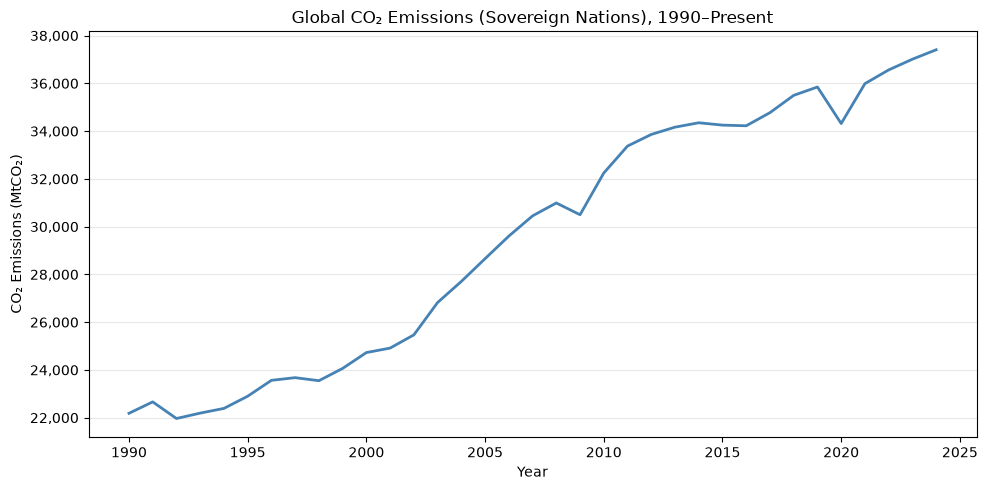

In [11]:
global_co2 = df_filtered.groupby('year')['co2'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(global_co2['year'], global_co2['co2'], linewidth=2, color='steelblue')
ax.set_title('Global CO₂ Emissions (Sovereign Nations), 1990–Present')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ Emissions (MtCO₂)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** Global CO₂ emissions rose steadily from around 23,000 MtCO₂ in 1990 to around 36,000 MtCO₂ in 2019, with emissions continuing to rise to a peak of roughly 37,400 MtCO₂ in 2024, driven primarily by rapid industrialisation in Asia. Two clear inflection points are visible: a brief dip around 2008–2009 coinciding with the global financial crisis, and a sharper drop in 2020 caused by COVID-19 pandemic-related lockdowns and reduced economic activity. Emissions rebounded quickly in 2021 as economies reopened, suggesting the pandemic effect was transient rather than structural. The overall trend remains upward, though the rate of growth has moderated in the 2010s compared to the 2000s, likely reflecting improving energy efficiency and growing renewable energy deployment in major economies.

#### Chart 2 — CO₂ Trends for Top 5 Emitting Countries

**What to do:** Filter `df_filtered` to China, USA ("United States"), India, Russia, and Japan. Plot a multi-line chart with one line per country.


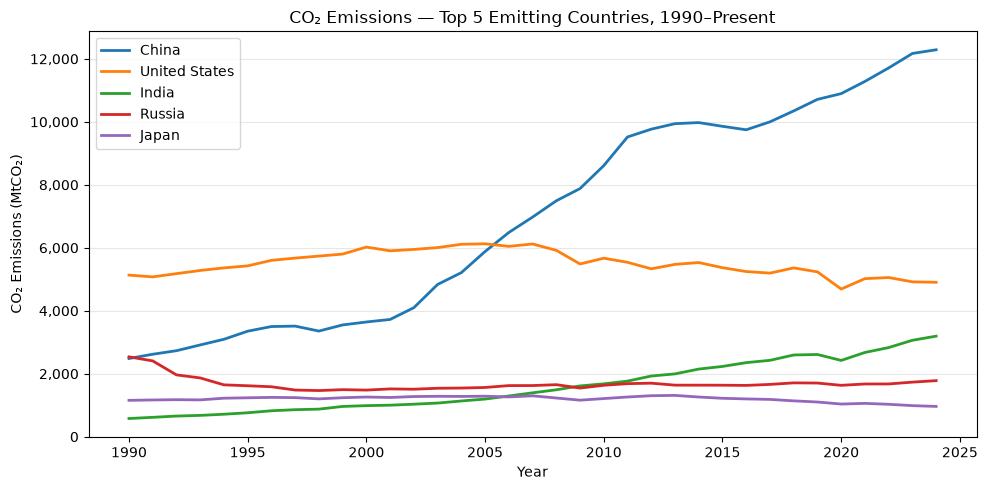

In [12]:
TOP5 = ['China', 'United States', 'India', 'Russia', 'Japan']
df_top5 = df_filtered[df_filtered['country'].isin(TOP5)].copy().sort_values(['country', 'year'])

fig, ax = plt.subplots(figsize=(10, 5))
for country in TOP5:
    data = df_top5[df_top5['country'] == country]
    ax.plot(data['year'], data['co2'], label=country, linewidth=2)

ax.set_title('CO₂ Emissions — Top 5 Emitting Countries, 1990–Present')
ax.set_xlabel('Year')
ax.set_ylabel('CO₂ Emissions (MtCO₂)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** China's trajectory stands out dramatically — it more than tripled its CO₂ output between 1990 and 2014, overtaking the United States around 2006 to become the world's largest emitter by a wide margin. The United States shows a broadly flat-to-declining trend since the mid-2000s, reflecting a shift from coal to natural gas and growing renewable energy adoption. India shows a steady, accelerating upward trajectory throughout the period, reflecting its rapid economic growth and expanding electricity demand. Russia and Japan both remain relatively flat over the full period, with Russia's emissions dipping sharply in the early 1990s following the post-Soviet economic contraction. These divergent patterns illustrate how emissions trajectories are shaped by the intersection of economic growth stage, energy mix, and policy environment.

#### Chart 3 — Share of Global GHG by Gas Type per Decade

**What to do:** Add a `decade` column (`(df['year'] // 10) * 10`), group by decade, sum CO₂/CH₄/N₂O columns across all countries, normalise to percentages, and plot as a stacked bar chart.


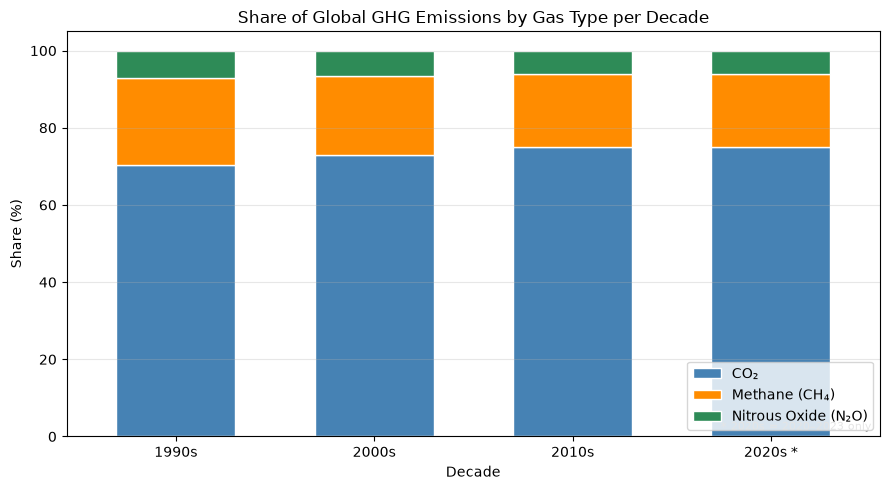

In [13]:
gas_cols = ['co2', 'methane', 'nitrous_oxide']

# Note: groupby().sum() treats NaN as 0 by default. Countries that do not report
# methane or N₂O contribute 0 to those columns but their full CO₂ to the total,
# which slightly overstates CO₂'s share. The 2020s bar covers only 2020–2023
# (4 years) — proportions are still valid, but absolute totals would be lower.
decade_key = (df_filtered['year'] // 10) * 10   # Series used as groupby key; avoids mutating df_filtered
decade_sums = df_filtered.groupby(decade_key)[gas_cols].sum()
decade_pct = decade_sums.div(decade_sums.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
decade_pct.plot(
    kind='bar', stacked=True, ax=ax,
    color=['steelblue', 'darkorange', 'seagreen'],
    edgecolor='white', width=0.6
)
ax.set_title('Share of Global GHG Emissions by Gas Type per Decade')
ax.set_xlabel('Decade')
ax.set_ylabel('Share (%)')
ax.set_xticklabels(
    [f"{int(d)}s" + (" *" if d == 2020 else "") for d in decade_pct.index],
    rotation=0
)
ax.legend(['CO₂', 'Methane (CH₄)', 'Nitrous Oxide (N₂O)'], loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.text(0.99, 0.01, '* 2020s = 2020–2023 only', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=8, color='grey')
plt.tight_layout()
plt.show()

**Observation:** CO₂ consistently dominates the GHG mix, accounting for approximately 70–75% of total emissions across all decades, with its share showing a modest upward trend over time as fossil fuel combustion has grown faster than agricultural sources. Methane (CH₄) is the second-largest contributor at around 20–25%, arising primarily from livestock, rice cultivation, and natural gas leakage; its share has remained relatively stable. Nitrous oxide (N₂O), largely driven by synthetic fertiliser use and livestock waste, accounts for the remaining 5–8% and has also held roughly constant. The stability of the gas-type composition across decades suggests that while total emissions have grown substantially, the underlying structure of global GHG production has not shifted dramatically — decarbonisation of the electricity sector (which primarily reduces CO₂) would need to be accompanied by agricultural methane reductions to substantially change this mix.

### Week 1 Summary

The OWID CO₂ dataset is a rich, wide-format panel covering ~200 sovereign nations from 1990 to 2023, with 70+ columns spanning emissions by gas type, per-capita and intensity measures, energy mix, GDP, and population. Many columns — particularly economic and non-CO₂ gas columns — have significant missingness for earlier years and smaller nations, so filtering to post-1990 data and excluding regional aggregates was essential before any analysis. The global CO₂ trend reveals steady growth punctuated by two clear demand shocks (2008–09 and 2020), with the 2020 pandemic dip quickly reversed — suggesting that structural change rather than crisis-driven disruption is needed to bend the curve. Disaggregating by country exposes the critical role of China, whose tripling of output since 1990 accounts for most of global emissions growth, while the USA and developed economies show plateaus or modest declines. Finally, the gas-type breakdown shows that CO₂ dominates and its share is growing, while methane and N₂O shares are stable — a finding that will inform our modelling focus on CO₂ as the primary target variable in the weeks ahead.

---
> **Commit before your Week 1 mentor session:**
> ```
> git add notebook/week1_eda.ipynb
> git commit -m "Week 1: data loading, profiling, and EDA complete"
> git push
> ```